time grid: dt 0.05 s | training window 0 to 10 s (200 steps) | full horizon 0 to 30 s (600 steps)
damping values: 24 total | train 17 | test 7 | disjoint: True
train b range 0.083 to 0.390 | test b range 0.072 to 0.391
trajectories: train (102, 601, 2) test (42, 601, 2) | states are (theta, omega); initial angles (rad): [0.6 1.  1.4 1.8 2.2 2.6]


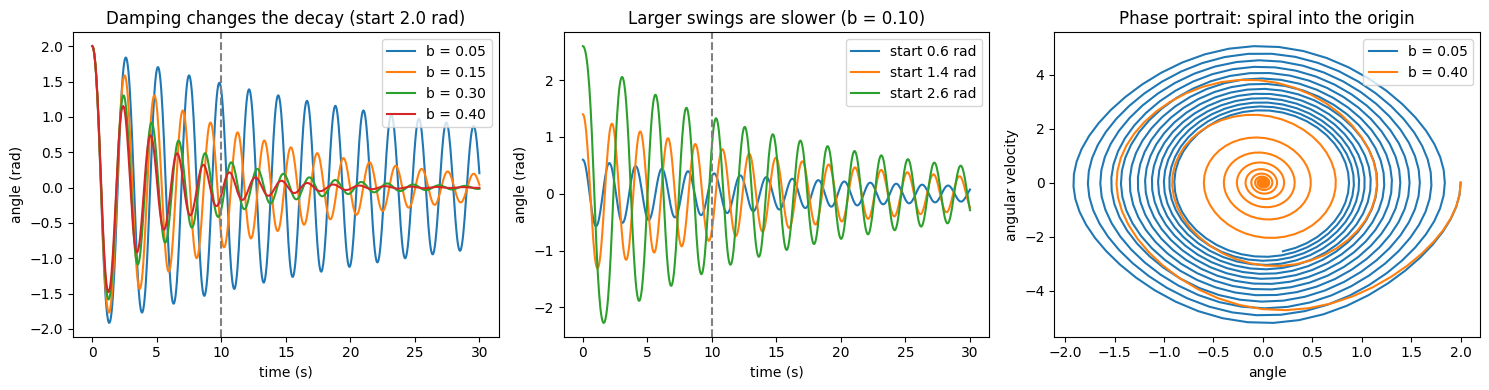

time of the first half-swing (b = 0.05): start 0.6 rad 1.05 s | start 2.6 rad 1.70 s | small-angle half period 1.00 s
test trajectories: peak |angle| near t = 10 s: median 0.373 | near t = 30 s: median 0.0287 (min 0.00238)
RK4 with dt 0.05 s against the accurate reference over 30 s: worst absolute error 5.69e-04 (so the solver adds negligible error)


In [6]:
import numpy as np, matplotlib
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import os
WORK = "/kaggle/working" if os.path.exists("/kaggle/working") else "/tmp/node/work"
os.makedirs(f"{WORK}/results", exist_ok=True)

G, L = 9.81, 1.0
DT, T_TRAIN, T_TOTAL = 0.05, 10.0, 30.0
t_eval = np.arange(0.0, T_TOTAL + 1e-9, DT)
n_train_steps = int(round(T_TRAIN / DT))

def pendulum(t, z, b):
    return [z[1], -b * z[1] - (G / L) * np.sin(z[0])]

def simulate(b, theta0):
    sol = solve_ivp(pendulum, (0.0, T_TOTAL), [theta0, 0.0], t_eval=t_eval, args=(b,), method="DOP853", rtol=1e-10, atol=1e-12)
    return sol.y.T

rng = np.random.default_rng(42)
b_values = np.sort(rng.uniform(0.05, 0.40, 24))
theta0s = np.linspace(0.6, 2.6, 6)
perm = rng.permutation(len(b_values)); n_tr = int(round(0.7 * len(b_values)))
b_train, b_test = np.sort(b_values[perm[:n_tr]]), np.sort(b_values[perm[n_tr:]])
assert len(set(b_train) & set(b_test)) == 0

def build(bs):
    Z, B = [], []
    for b in bs:
        for th in theta0s:
            Z.append(simulate(b, th)); B.append(b)
    return np.array(Z), np.array(B)
Z_train, B_train = build(b_train); Z_test, B_test = build(b_test)
print("time grid: dt %.2f s | training window 0 to %.0f s (%d steps) | full horizon 0 to %.0f s (%d steps)" % (DT, T_TRAIN, n_train_steps, T_TOTAL, len(t_eval) - 1))
print("damping values: %d total | train %d | test %d | disjoint: %s" % (len(b_values), len(b_train), len(b_test), len(set(b_train) & set(b_test)) == 0))
print("train b range %.3f to %.3f | test b range %.3f to %.3f" % (b_train.min(), b_train.max(), b_test.min(), b_test.max()))
print("trajectories: train", Z_train.shape, "test", Z_test.shape, "| states are (theta, omega); initial angles (rad):", np.round(theta0s, 2))

fig, ax = plt.subplots(1, 3, figsize=(15,4))
for b in (0.05, 0.15, 0.3, 0.4):
    z = simulate(b, 2.0); ax[0].plot(t_eval, z[:, 0], label="b = %.2f" % b)
ax[0].axvline(T_TRAIN, color="gray", linestyle="--"); ax[0].set_xlabel("time (s)"); ax[0].set_ylabel("angle (rad)"); ax[0].legend(); ax[0].set_title("Damping changes the decay (start 2.0 rad)")
for th in (0.6, 1.4, 2.6):
    z = simulate(0.1, th); ax[1].plot(t_eval, z[:, 0], label="start %.1f rad" % th)
ax[1].axvline(T_TRAIN, color="gray", linestyle="--"); ax[1].set_xlabel("time (s)"); ax[1].set_ylabel("angle (rad)"); ax[1].legend(); ax[1].set_title("Larger swings are slower (b = 0.10)")
for b in (0.05, 0.4):
    z = simulate(b, 2.0); ax[2].plot(z[:, 0], z[:, 1], label="b = %.2f" % b)
ax[2].set_xlabel("angle"); ax[2].set_ylabel("angular velocity"); ax[2].legend(); ax[2].set_title("Phase portrait: spiral into the origin")
plt.tight_layout(); plt.savefig(f"{WORK}/results/node_trajectories.png", dpi=150, bbox_inches="tight"); plt.show()

def half_period(b, th):
    z = simulate(b, th); idx = np.where((z[1:, 1] > 0) & (z[:-1, 1] <= 0))[0]
    return t_eval[idx[0] + 1] if len(idx) else float("nan")
print("time of the first half-swing (b = 0.05): start 0.6 rad %.2f s | start 2.6 rad %.2f s | small-angle half period %.2f s" % (half_period(0.05, 0.6), half_period(0.05, 2.6), np.pi / np.sqrt(G / L)))
amp10 = np.abs(Z_test[:, int(10 / DT):int(10 / DT) + 40, 0]).max(1); amp30 = np.abs(Z_test[:, -40:, 0]).max(1)
print("test trajectories: peak |angle| near t = 10 s: median %.3f | near t = 30 s: median %.4f (min %.5f)" % (np.median(amp10), np.median(amp30), amp30.min()))

def rk4(f, z, h):
    k1 = f(z); k2 = f(z + 0.5 * h * k1); k3 = f(z + 0.5 * h * k2); k4 = f(z + h * k3)
    return z + h * (k1 + 2 * k2 + 2 * k3 + k4) / 6.0
worst = 0.0
for b in (0.05, 0.4):
    for th in (0.6, 2.6):
        f = lambda z: np.array([z[1], -b * z[1] - (G / L) * np.sin(z[0])])
        z = np.array([th, 0.0]); path = [z]
        for _ in range(len(t_eval) - 1):
            z = rk4(f, z, DT); path.append(z)
        worst = max(worst, np.abs(np.array(path) - simulate(b, th)).max())
print("RK4 with dt %.2f s against the accurate reference over 30 s: worst absolute error %.2e (so the solver adds negligible error)" % (DT, worst))
np.savez(f"{WORK}/pendulum_data.npz", Z_train=Z_train, B_train=B_train, Z_test=Z_test, B_test=B_test, t=t_eval)

In [7]:
import torch, torch.nn as nn, time
import pandas as pd
torch.set_num_threads(4); torch.manual_seed(42); np.random.seed(42)
d = np.load(f"{WORK}/pendulum_data.npz")
Ztr, Btr, Zte, Bte = [torch.tensor(d[k], dtype=torch.float32) for k in ("Z_train", "B_train", "Z_test", "B_test")]
N_TRAIN, N_FULL = n_train_steps, len(t_eval) - 1

class Field(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(3, hidden), nn.Tanh(), nn.Linear(hidden, hidden), nn.Tanh(), nn.Linear(hidden, 2))
    def forward(self, z, b):
        x = torch.cat([z[:, :1], z[:, 1:] / 3.0, 5.0 * b.unsqueeze(1)], dim=1)
        return 5.0 * self.net(x)

def rk4_step(f, z, b, h):
    k1 = f(z, b); k2 = f(z + 0.5 * h * k1, b); k3 = f(z + 0.5 * h * k2, b); k4 = f(z + h * k3, b)
    return z + h * (k1 + 2 * k2 + 2 * k3 + k4) / 6.0

def rollout(f, z0, b, steps, h=DT):
    zs = [z0]; z = z0
    for _ in range(steps):
        z = rk4_step(f, z, b, h); zs.append(z)
    return torch.stack(zs, dim=1)

true_field = lambda z, b: torch.stack([z[:, 1], -b * z[:, 1] - (G / L) * torch.sin(z[:, 0])], dim=1)
with torch.no_grad():
    chk = rollout(true_field, Zte[:, 0].double(), Bte.double(), N_FULL)
print("solver check: torch RK4 with the true vector field against the reference, all test trajectories, 30 s: max error %.2e" % (chk - Zte.double()).abs().max().item())

def train_node(Z, B, epochs=300, lr=3e-3, seed=42, weight_decay=0.0, verbose=True):
    torch.manual_seed(seed)
    f = Field(); opt = torch.optim.Adam(f.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr / 10)
    log, t0 = [], time.time()
    for ep in range(epochs):
        steps = 40 if ep < epochs * 0.3 else (100 if ep < epochs * 0.6 else N_TRAIN)
        opt.zero_grad()
        pred = rollout(f, Z[:, 0], B, steps)
        loss = ((pred - Z[:, :steps + 1]) ** 2).mean()
        loss.backward(); torch.nn.utils.clip_grad_norm_(f.parameters(), 5.0); opt.step(); sched.step()
        log.append((ep + 1, steps, loss.item()))
        if verbose and (ep % 50 == 0 or ep == epochs - 1): print("  epoch %d | window %d steps | loss %.5f | %.0f s" % (log[-1] + (time.time() - t0,)))
    return f, log

print("Neural ODE vector field parameters:", sum(p.numel() for p in Field().parameters()))
t0 = time.time(); f_node, log_node = train_node(Ztr, Btr)
print("Neural ODE trained in %.0f s" % (time.time() - t0))
with torch.no_grad():
    pred_node = rollout(f_node, Zte[:, 0], Bte, N_FULL)
print("quick look, test RMSE: first 10 s %.4f | 10 to 30 s %.4f" % (((pred_node[:, :N_TRAIN + 1] - Zte[:, :N_TRAIN + 1]) ** 2).mean().sqrt().item(), ((pred_node[:, N_TRAIN:] - Zte[:, N_TRAIN:]) ** 2).mean().sqrt().item()))

solver check: torch RK4 with the true vector field against the reference, all test trajectories, 30 s: max error 3.73e-04
Neural ODE vector field parameters: 4546
  epoch 1 | window 40 steps | loss 5.43845 | 0 s
  epoch 51 | window 40 steps | loss 0.14288 | 5 s
  epoch 101 | window 100 steps | loss 0.16175 | 12 s
  epoch 151 | window 100 steps | loss 0.08114 | 25 s
  epoch 201 | window 200 steps | loss 0.18256 | 44 s
  epoch 251 | window 200 steps | loss 0.09302 | 69 s
  epoch 300 | window 200 steps | loss 0.07268 | 95 s
Neural ODE trained in 101 s
quick look, test RMSE: first 10 s 0.3810 | 10 to 30 s 0.6720


In [8]:
class StepLSTM(nn.Module):
    def __init__(self, hidden=64, layers=2):
        super().__init__()
        self.rnn = nn.LSTM(3, hidden, layers, batch_first=True)
        self.out = nn.Linear(hidden, 2)
    def forward(self, x, state=None):
        o, state = self.rnn(x, state)
        return self.out(o), state

def lstm_inputs(z, b):
    return torch.stack([z[..., 0], z[..., 1] / 3.0, 5.0 * b.unsqueeze(-1).expand_as(z[..., 0])], dim=-1)

def train_lstm(Z, B, epochs=300, lr=3e-3, seed=42, verbose=True):
    torch.manual_seed(seed)
    m = StepLSTM(); opt = torch.optim.Adam(m.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr / 10)
    x = lstm_inputs(Z[:, :N_TRAIN], B); y = (Z[:, 1:N_TRAIN + 1] - Z[:, :N_TRAIN]) / 0.25
    log, t0 = [], time.time()
    for ep in range(epochs):
        opt.zero_grad(); pred, _ = m(x); loss = ((pred - y) ** 2).mean()
        loss.backward(); torch.nn.utils.clip_grad_norm_(m.parameters(), 5.0); opt.step(); sched.step()
        log.append((ep + 1, loss.item()))
        if verbose and (ep % 50 == 0 or ep == epochs - 1): print("  epoch %d | one-step loss %.5f | %.0f s" % (log[-1] + (time.time() - t0,)))
    return m, log

@torch.no_grad()
def predict_lstm(m, z0, b, steps=N_FULL):
    zs = [z0]; z = z0; state = None
    for _ in range(steps):
        o, state = m(lstm_inputs(z.unsqueeze(1), b), state)
        z = z + 0.25 * o[:, 0]; zs.append(z)
    return torch.stack(zs, dim=1)

print("LSTM baseline parameters:", sum(p.numel() for p in StepLSTM().parameters()), "(Neural ODE vector field: %d)" % sum(p.numel() for p in Field().parameters()))
t0 = time.time(); m_lstm, log_lstm = train_lstm(Ztr, Btr)
print("LSTM trained in %.0f s" % (time.time() - t0))
pred_lstm = predict_lstm(m_lstm, Zte[:, 0], Bte)
print("quick look, test RMSE: first 10 s %.4f | 10 to 30 s %.4f" % (((pred_lstm[:, :N_TRAIN + 1] - Zte[:, :N_TRAIN + 1]) ** 2).mean().sqrt().item(), ((pred_lstm[:, N_TRAIN:] - Zte[:, N_TRAIN:]) ** 2).mean().sqrt().item()))

LSTM baseline parameters: 51074 (Neural ODE vector field: 4546)
  epoch 1 | one-step loss 0.62589 | 0 s
  epoch 51 | one-step loss 0.01184 | 8 s
  epoch 101 | one-step loss 0.00691 | 15 s
  epoch 151 | one-step loss 0.00531 | 22 s
  epoch 201 | one-step loss 0.00452 | 30 s
  epoch 251 | one-step loss 0.00413 | 37 s
  epoch 300 | one-step loss 0.00395 | 44 s
LSTM trained in 44 s
quick look, test RMSE: first 10 s 0.6118 | 10 to 30 s 0.8015


TEST on unseen damping values (42 trajectories; lower half b <= 0.275):
                     model  RMSE 0-10 s (train window)  RMSE 10-30 s (extrapolation)  10-30 s, lower damping half  10-30 s, higher damping half
zero predictor (reference)                      1.5443                        0.6608                       0.8606                        0.1775
          Neural ODE (RK4)                      0.3810                        0.6720                       0.8828                        0.1198
      LSTM, one step ahead                      0.6118                        0.8015                       1.0588                        0.0637


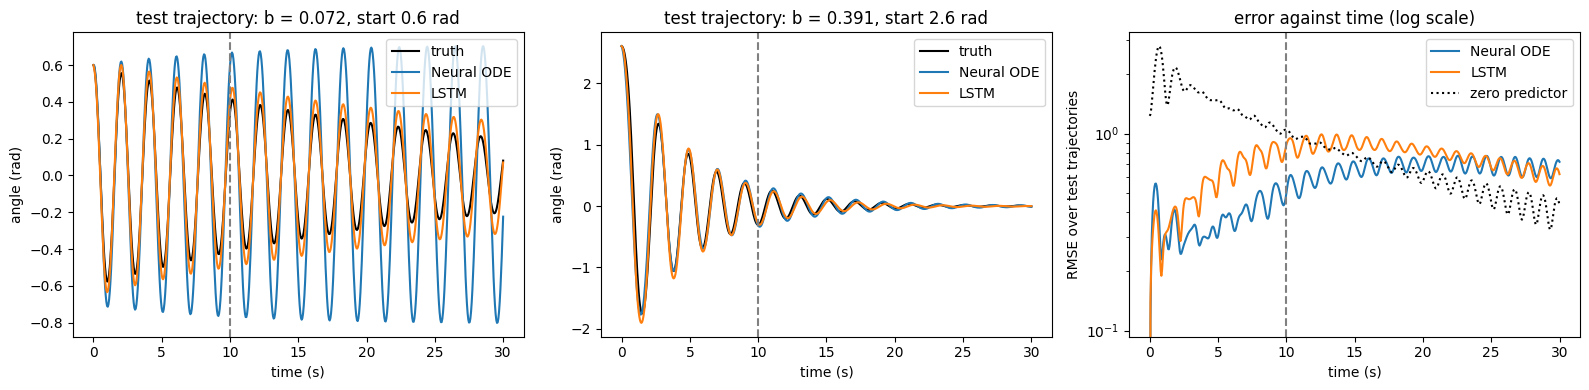

worst absolute error at any time, any test trajectory: Neural ODE 5.228 | LSTM 6.728


In [9]:
def rmse_windows(pred, Z, idx=None):
    idx = slice(None) if idx is None else idx
    a = ((pred[idx, :N_TRAIN + 1] - Z[idx, :N_TRAIN + 1]) ** 2).mean().sqrt().item()
    b_ = ((pred[idx, N_TRAIN:] - Z[idx, N_TRAIN:]) ** 2).mean().sqrt().item()
    return a, b_
zeros = torch.zeros_like(Zte)
low = torch.where(Bte <= Bte.median())[0]; high = torch.where(Bte > Bte.median())[0]
rows = []
for name, p in (("zero predictor (reference)", zeros), ("Neural ODE (RK4)", pred_node), ("LSTM, one step ahead", pred_lstm)):
    r_all, r_low, r_high = rmse_windows(p, Zte), rmse_windows(p, Zte, low), rmse_windows(p, Zte, high)
    rows.append((name, r_all[0], r_all[1], r_low[1], r_high[1]))
tab = pd.DataFrame(rows, columns=["model", "RMSE 0-10 s (train window)", "RMSE 10-30 s (extrapolation)", "10-30 s, lower damping half", "10-30 s, higher damping half"])
print("TEST on unseen damping values (%d trajectories; lower half b <= %.3f):" % (len(Zte), Bte.median().item())); print(tab.round(4).to_string(index=False))

err_node = ((pred_node - Zte) ** 2).mean(dim=(0, 2)).sqrt().numpy(); err_lstm = ((pred_lstm - Zte) ** 2).mean(dim=(0, 2)).sqrt().numpy(); err_zero = (Zte ** 2).mean(dim=(0, 2)).sqrt().numpy()
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for a_, i in zip(ax[:2], (int(low[0]), int(high[-1]))):
    a_.plot(t_eval, Zte[i, :, 0], "k", label="truth"); a_.plot(t_eval, pred_node[i, :, 0], label="Neural ODE"); a_.plot(t_eval, pred_lstm[i, :, 0], label="LSTM")
    a_.axvline(T_TRAIN, color="gray", linestyle="--"); a_.set_xlabel("time (s)"); a_.set_ylabel("angle (rad)"); a_.legend(); a_.set_title("test trajectory: b = %.3f, start %.1f rad" % (Bte[i], Zte[i, 0, 0]))
ax[2].plot(t_eval, err_node, label="Neural ODE"); ax[2].plot(t_eval, err_lstm, label="LSTM"); ax[2].plot(t_eval, err_zero, "k:", label="zero predictor")
ax[2].axvline(T_TRAIN, color="gray", linestyle="--"); ax[2].set_xlabel("time (s)"); ax[2].set_ylabel("RMSE over test trajectories"); ax[2].set_yscale("log"); ax[2].legend(); ax[2].set_title("error against time (log scale)")
plt.tight_layout(); plt.savefig(f"{WORK}/results/node_vs_lstm.png", dpi=150, bbox_inches="tight"); plt.show()
print("worst absolute error at any time, any test trajectory: Neural ODE %.3f | LSTM %.3f" % ((pred_node - Zte).abs().max().item(), (pred_lstm - Zte).abs().max().item()))

noise sigma 0.02 done in 141 s | Neural ODE: 0.4000 / 0.7046 | LSTM: 0.6327 / 0.8102 (RMSE 0-10 s / 10-30 s)
noise sigma 0.05 done in 138 s | Neural ODE: 0.3504 / 0.5372 | LSTM: 0.7187 / 0.8210 (RMSE 0-10 s / 10-30 s)
noise sigma 0.10 done in 139 s | Neural ODE: 0.3758 / 0.6101 | LSTM: 0.9496 / 0.8404 (RMSE 0-10 s / 10-30 s)
test RMSE (clean test trajectories, unseen damping values) after training on noisy data:
 noise sigma  Neural ODE 0-10 s  Neural ODE 10-30 s  LSTM 0-10 s  LSTM 10-30 s
        0.00             0.3810              0.6720       0.6118        0.8015
        0.02             0.4000              0.7046       0.6327        0.8102
        0.05             0.3504              0.5372       0.7187        0.8210
        0.10             0.3758              0.6101       0.9496        0.8404


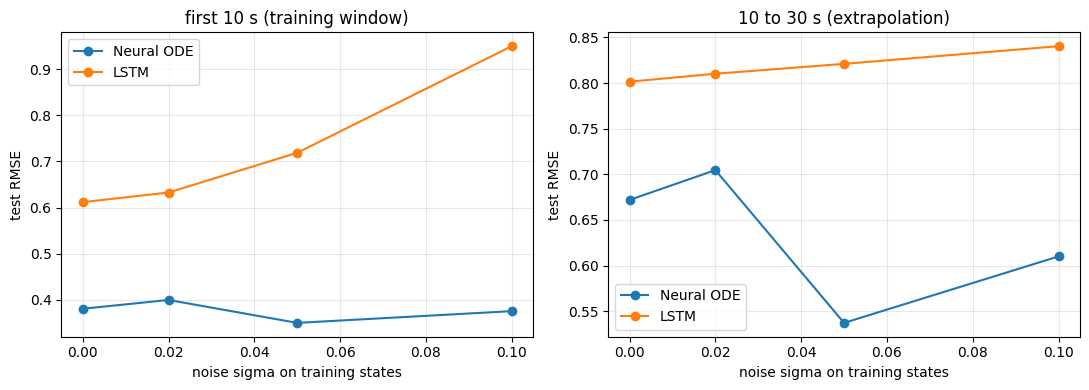

In [10]:
sigmas = [0.0, 0.02, 0.05, 0.1]; res = {0.0: (rmse_windows(pred_node, Zte), rmse_windows(pred_lstm, Zte))}
gen = torch.Generator().manual_seed(0)
for s in sigmas[1:]:
    Zn = Ztr + s * torch.randn(Ztr.shape, generator=gen)
    t0 = time.time(); fn, _ = train_node(Zn, Btr, verbose=False); ml, _ = train_lstm(Zn, Btr, verbose=False)
    with torch.no_grad():
        pn = rollout(fn, Zte[:, 0], Bte, N_FULL)
    pl = predict_lstm(ml, Zte[:, 0], Bte)
    res[s] = (rmse_windows(pn, Zte), rmse_windows(pl, Zte))
    print("noise sigma %.2f done in %.0f s | Neural ODE: %.4f / %.4f | LSTM: %.4f / %.4f (RMSE 0-10 s / 10-30 s)" % ((s, time.time() - t0) + res[s][0] + res[s][1]))
tab = pd.DataFrame([(s, res[s][0][0], res[s][0][1], res[s][1][0], res[s][1][1]) for s in sigmas], columns=["noise sigma", "Neural ODE 0-10 s", "Neural ODE 10-30 s", "LSTM 0-10 s", "LSTM 10-30 s"])
print("test RMSE (clean test trajectories, unseen damping values) after training on noisy data:"); print(tab.round(4).to_string(index=False))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a_, j, title in ((ax[0], 1, "first 10 s (training window)"), (ax[1], 2, "10 to 30 s (extrapolation)")):
    a_.plot(tab["noise sigma"], tab.iloc[:, j], marker="o", label="Neural ODE"); a_.plot(tab["noise sigma"], tab.iloc[:, j + 2], marker="o", label="LSTM")
    a_.set_xlabel("noise sigma on training states"); a_.set_ylabel("test RMSE"); a_.legend(); a_.grid(alpha=0.3); a_.set_title(title)
plt.tight_layout(); plt.savefig(f"{WORK}/results/node_noise.png", dpi=150, bbox_inches="tight"); plt.show()

In [11]:
bvals = torch.unique(Bte); rows = []
for bv in bvals:
    idx = torch.where(Bte == bv)[0]
    inside = "inside" if (bv >= Btr.min() and bv <= Btr.max()) else "OUTSIDE"
    row = [round(float(bv), 3), inside]
    for p in (zeros, pred_node, pred_lstm):
        row.append(((p[idx, N_TRAIN:] - Zte[idx, N_TRAIN:]) ** 2).mean().sqrt().item())
    rows.append(row + [(Zte[idx, N_TRAIN:] ** 2).mean().sqrt().item()])
print("RMSE over 10-30 s for each unseen damping value (6 start angles each); training b range %.3f to %.3f:" % (Btr.min(), Btr.max()))
print(pd.DataFrame(rows, columns=["damping b", "vs training range", "zero predictor", "Neural ODE", "LSTM", "truth RMS (10-30 s)"]).round(4).to_string(index=False))
for name, p in (("Neural ODE", pred_node), ("LSTM", pred_lstm)):
    out = []
    for w_name, sl in (("0-10 s", slice(0, N_TRAIN + 1)), ("10-30 s", slice(N_TRAIN, None))):
        e = ((p[:, sl] - Zte[:, sl]) ** 2).sum(dim=(1, 2)).sqrt(); t_ = (Zte[:, sl] ** 2).sum(dim=(1, 2)).sqrt(); r = e / t_
        out.append("%s: median %.2f, mean %.2f, %.0f%% of trajectories worse than predicting zero" % (w_name, r.median().item(), r.mean().item(), 100 * (r > 1).float().mean().item()))
    print("%-10s relative error (RMSE divided by the RMS of the truth; 1.0 = no better than zero) | " % name + " | ".join(out))
    

RMSE over 10-30 s for each unseen damping value (6 start angles each); training b range 0.083 to 0.390:
 damping b vs training range  zero predictor  Neural ODE   LSTM  truth RMS (10-30 s)
     0.072           OUTSIDE          1.2393      1.3327 1.7152               1.2393
     0.095            inside          1.0240      0.8878 1.2176               1.0240
     0.174            inside          0.5526      0.6849 0.2419               0.5526
     0.275            inside          0.2695      0.2902 0.0388               0.2695
     0.321            inside          0.2001      0.1430 0.0584               0.2001
     0.325            inside          0.1947      0.1316 0.0599               0.1947
     0.391           OUTSIDE          0.1286      0.0728 0.0721               0.1286
Neural ODE relative error (RMSE divided by the RMS of the truth; 1.0 = no better than zero) | 0-10 s: median 0.19, mean 0.22, 0% of trajectories worse than predicting zero | 10-30 s: median 0.90, mean 1.01, 45% of tr

Neural ODE, 1200 epochs: 376 s | final training loss 0.02673 (300-epoch run: 0.07268)
LSTM, 1200 epochs: 179 s | final one-step loss 0.00039 (300-epoch run: 0.00395)
Neural ODE RMSE on its own training trajectories (0-10 s): 300 epochs 0.2888 | 1200 epochs 0.1464
TEST on unseen damping values:
                     model  RMSE 0-10 s  RMSE 10-30 s  10-30 s, lower damping half  10-30 s, higher damping half
zero predictor (reference)       1.5443        0.6608                       0.8606                        0.1775
    Neural ODE, 300 epochs       0.3810        0.6720                       0.8828                        0.1198
   Neural ODE, 1200 epochs       0.1791        0.2887                       0.3809                        0.0321
          LSTM, 300 epochs       0.6118        0.8015                       1.0588                        0.0637
         LSTM, 1200 epochs       0.2179        0.3886                       0.5140                        0.0140


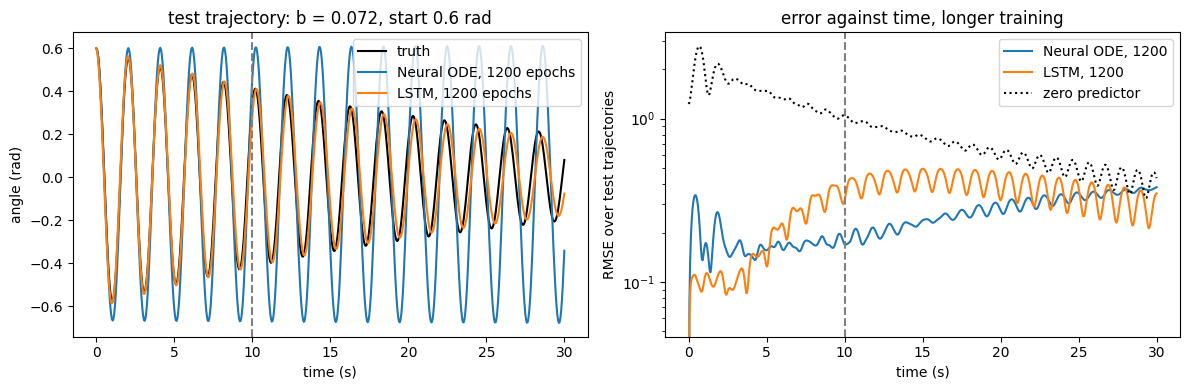

In [12]:
t0 = time.time(); f_node2, log_node2 = train_node(Ztr, Btr, epochs=1200, verbose=False)
print("Neural ODE, 1200 epochs: %.0f s | final training loss %.5f (300-epoch run: %.5f)" % (time.time() - t0, log_node2[-1][2], log_node[-1][2]))
t0 = time.time(); m_lstm2, log_lstm2 = train_lstm(Ztr, Btr, epochs=1200, verbose=False)
print("LSTM, 1200 epochs: %.0f s | final one-step loss %.5f (300-epoch run: %.5f)" % (time.time() - t0, log_lstm2[-1][1], log_lstm[-1][1]))
with torch.no_grad():
    pred_node2 = rollout(f_node2, Zte[:, 0], Bte, N_FULL)
    fit_node = ((rollout(f_node, Ztr[:, 0], Btr, N_TRAIN) - Ztr[:, :N_TRAIN + 1]) ** 2).mean().sqrt().item()
    fit_node2 = ((rollout(f_node2, Ztr[:, 0], Btr, N_TRAIN) - Ztr[:, :N_TRAIN + 1]) ** 2).mean().sqrt().item()
pred_lstm2 = predict_lstm(m_lstm2, Zte[:, 0], Bte)
print("Neural ODE RMSE on its own training trajectories (0-10 s): 300 epochs %.4f | 1200 epochs %.4f" % (fit_node, fit_node2))
rows = []
for name, p in (("zero predictor (reference)", zeros), ("Neural ODE, 300 epochs", pred_node), ("Neural ODE, 1200 epochs", pred_node2), ("LSTM, 300 epochs", pred_lstm), ("LSTM, 1200 epochs", pred_lstm2)):
    r_all, r_low, r_high = rmse_windows(p, Zte), rmse_windows(p, Zte, low), rmse_windows(p, Zte, high)
    rows.append((name, r_all[0], r_all[1], r_low[1], r_high[1]))
print("TEST on unseen damping values:"); print(pd.DataFrame(rows, columns=["model", "RMSE 0-10 s", "RMSE 10-30 s", "10-30 s, lower damping half", "10-30 s, higher damping half"]).round(4).to_string(index=False))
fig, ax = plt.subplots(1, 2, figsize=(12, 4)); i = int(low[0])
ax[0].plot(t_eval, Zte[i, :, 0], "k", label="truth"); ax[0].plot(t_eval, pred_node2[i, :, 0], label="Neural ODE, 1200 epochs"); ax[0].plot(t_eval, pred_lstm2[i, :, 0], label="LSTM, 1200 epochs")
ax[0].axvline(T_TRAIN, color="gray", linestyle="--"); ax[0].set_xlabel("time (s)"); ax[0].set_ylabel("angle (rad)"); ax[0].legend(); ax[0].set_title("test trajectory: b = %.3f, start %.1f rad" % (Bte[i], Zte[i, 0, 0]))
for lab, p in (("Neural ODE, 1200", pred_node2), ("LSTM, 1200", pred_lstm2)):
    ax[1].plot(t_eval, ((p - Zte) ** 2).mean(dim=(0, 2)).sqrt().numpy(), label=lab)
ax[1].plot(t_eval, (Zte ** 2).mean(dim=(0, 2)).sqrt().numpy(), "k:", label="zero predictor"); ax[1].axvline(T_TRAIN, color="gray", linestyle="--")
ax[1].set_yscale("log"); ax[1].set_xlabel("time (s)"); ax[1].set_ylabel("RMSE over test trajectories"); ax[1].legend(); ax[1].set_title("error against time, longer training")
plt.tight_layout(); plt.savefig(f"{WORK}/results/node_longer_training.png", dpi=150, bbox_inches="tight"); plt.show()

In [13]:
gen = torch.Generator().manual_seed(0); noisy = {}
for s in (0.02, 0.05, 0.1): noisy[s] = Ztr + s * torch.randn(Ztr.shape, generator=gen)
Zn = noisy[0.1]

def train_node_v(Z, B, hidden=64, weight_decay=0.0, epochs=300, lr=3e-3, seed=42):
    torch.manual_seed(seed)
    f = Field(hidden); opt = torch.optim.Adam(f.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr / 10)
    for ep in range(epochs):
        steps = 40 if ep < epochs * 0.3 else (100 if ep < epochs * 0.6 else N_TRAIN)
        opt.zero_grad(); pred = rollout(f, Z[:, 0], B, steps)
        loss = ((pred - Z[:, :steps + 1]) ** 2).mean(); loss.backward()
        torch.nn.utils.clip_grad_norm_(f.parameters(), 5.0); opt.step(); sched.step()
    return f

variants = [("baseline, seed 43", dict(seed=43)), ("baseline, seed 44", dict(seed=44)), ("weight decay 1e-3", dict(weight_decay=1e-3)),
            ("hidden 16", dict(hidden=16)), ("hidden 128", dict(hidden=128))]
rows = [("baseline, seed 42 (from the noise table)", sum(p.numel() for p in Field(64).parameters())) + res[0.1][0]]
for name, kw in variants:
    t0 = time.time(); f = train_node_v(Zn, Btr, **kw)
    with torch.no_grad():
        pred = rollout(f, Zte[:, 0], Bte, N_FULL)
    r = rmse_windows(pred, Zte); rows.append((name, sum(p.numel() for p in Field(kw.get("hidden", 64)).parameters())) + r)
    print("%-20s done in %.0f s | RMSE 0-10 s %.4f | 10-30 s %.4f" % ((name, time.time() - t0) + r))
tab = pd.DataFrame(rows, columns=["Neural ODE variant (trained at sigma 0.1)", "parameters", "RMSE 0-10 s", "RMSE 10-30 s"])
print(tab.round(4).to_string(index=False))
print("reference at sigma 0.1: LSTM %.4f / %.4f | zero predictor 10-30 s %.4f" % (res[0.1][1][0], res[0.1][1][1], rmse_windows(zeros, Zte)[1]))
base = [rows[0][3]] + [r[3] for r in rows[1:3]]
print("baseline 10-30 s over seeds 42, 43, 44: %s | spread (max - min) %.4f" % ([round(x, 4) for x in base], max(base) - min(base)))

baseline, seed 43    done in 95 s | RMSE 0-10 s 0.3946 | 10-30 s 0.5229
baseline, seed 44    done in 94 s | RMSE 0-10 s 0.3939 | 10-30 s 0.6057
weight decay 1e-3    done in 94 s | RMSE 0-10 s 0.3715 | 10-30 s 0.5691
hidden 16            done in 73 s | RMSE 0-10 s 0.4707 | 10-30 s 0.6543
hidden 128           done in 113 s | RMSE 0-10 s 0.4154 | 10-30 s 0.6421
Neural ODE variant (trained at sigma 0.1)  parameters  RMSE 0-10 s  RMSE 10-30 s
 baseline, seed 42 (from the noise table)        4546       0.3758        0.6101
                        baseline, seed 43        4546       0.3946        0.5229
                        baseline, seed 44        4546       0.3939        0.6057
                        weight decay 1e-3        4546       0.3715        0.5691
                                hidden 16         370       0.4707        0.6543
                               hidden 128       17282       0.4154        0.6421
reference at sigma 0.1: LSTM 0.9496 / 0.8404 | zero predictor 10-30 s 0.

In [14]:
rows = []
for bv in torch.unique(Bte):
    idx = torch.where(Bte == bv)[0]
    row = [round(float(bv), 3)]
    for p in (zeros, pred_node2, pred_lstm2):
        row.append(((p[idx, N_TRAIN:] - Zte[idx, N_TRAIN:]) ** 2).mean().sqrt().item())
    rows.append(row)
print("RMSE over 10-30 s per unseen damping value, 1200-epoch models:")
print(pd.DataFrame(rows, columns=["damping b", "zero predictor", "Neural ODE 1200", "LSTM 1200"]).round(4).to_string(index=False))
for name, p in (("Neural ODE, 1200 epochs", pred_node2), ("LSTM, 1200 epochs", pred_lstm2)):
    out = []
    for w_name, sl in (("0-10 s", slice(0, N_TRAIN + 1)), ("10-30 s", slice(N_TRAIN, None))):
        e = ((p[:, sl] - Zte[:, sl]) ** 2).sum(dim=(1, 2)).sqrt(); t_ = (Zte[:, sl] ** 2).sum(dim=(1, 2)).sqrt(); r = e / t_
        out.append("%s: median %.2f, mean %.2f, %.0f%% of trajectories worse than predicting zero" % (w_name, r.median().item(), r.mean().item(), 100 * (r > 1).float().mean().item()))
    print("%-24s relative error | " % name + " | ".join(out))

RMSE over 10-30 s per unseen damping value, 1200-epoch models:
 damping b  zero predictor  Neural ODE 1200  LSTM 1200
     0.072          1.2393           0.6162     0.9204
     0.095          1.0240           0.4025     0.4550
     0.174          0.5526           0.1886     0.0467
     0.275          0.2695           0.0542     0.0177
     0.321          0.2001           0.0248     0.0149
     0.325          0.1947           0.0239     0.0147
     0.391          0.1286           0.0437     0.0121
Neural ODE, 1200 epochs  relative error | 0-10 s: median 0.09, mean 0.10, 0% of trajectories worse than predicting zero | 10-30 s: median 0.27, mean 0.35, 7% of trajectories worse than predicting zero
LSTM, 1200 epochs        relative error | 0-10 s: median 0.05, mean 0.07, 0% of trajectories worse than predicting zero | 10-30 s: median 0.11, mean 0.19, 2% of trajectories worse than predicting zero
